# Fixed point TRS partial transpose boundary operator extraction.
Created 03/26/2026

Objectives:
* Check in more depth the boundary operators for the cluster state.
* Are the resulting boundary operators unique up to a phase?
* What if we plug in the exact boundray operators into the optimisation function?

# Package imports

In [1]:
import sys
sys.path.append("../..")

In [2]:
from functools import reduce
from itertools import combinations

In [3]:
import h5py
from tenpy.tools import hdf5_io
import tenpy
import tenpy.linalg.np_conserved as npc

import os

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import unitary_group

In [5]:
from SPTOptimization.SymmetryActionWithBoundaryUnitaries import SymmetryActionWithBoundaryUnitaries
from SPTOptimization.Optimizers.utils import one_site_optimization

from SPTOptimization.gradients import expectation_gradient_from_environments_and_b_tensor

In [6]:
import quimb as qu
import quimb.tensor as qtn

/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:54: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(
/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:36: UserWarning: Couldn't import `kahypar` - skipping from default hyper optimizer and using basic `labels` method instead.
  warnings.warn(
/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:73: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(


# Load data

In [7]:
DATA_DIR = r"../../data/transverse_cluster_200_site_dmrg"

In [8]:
loaded_data = list()

for local_file_name in os.listdir(DATA_DIR):
    f_name = r"{}/{}".format(DATA_DIR, local_file_name, ignore_unknown=False)
    with h5py.File(f_name, 'r') as f:
        data = hdf5_io.load_from_hdf5(f)
        loaded_data.append(data)

In [9]:
b_parameters = sorted(list(d['paramters']['B'] for d in loaded_data))

In [10]:
def get_quimb_mps(tenpy_mps):
    psi_arrays = list()
    psi_arrays.append(tenpy_mps.get_B(0, 'Th')[0, ...].to_ndarray())
    for i in range(1, tenpy_mps.L-1):
        psi_arrays.append(tenpy_mps.get_B(i).to_ndarray())
    psi_arrays.append(tenpy_mps.get_B(tenpy_mps.L-1)[..., 0].to_ndarray())
    
    out = (
        qtn
        .tensor_1d
        .MatrixProductState(psi_arrays, shape='lpr')
    )

    return out

In [11]:
psi_dict = dict()

for b in b_parameters:
    psi = next(
        d['wavefunction']
        for d in loaded_data
        if d['paramters']['B'] == b
    )

    rounded_b = round(b, 1)
    psi_dict[rounded_b] = get_quimb_mps(psi)

# Definitions

In [12]:
np_I = np.array([[1,0],[0,1]])
np_X = np.array([[0,1],[1,0]])
np_Y = np.array([[0,-1j],[1j,0]])
np_Z = np.array([[1,0],[0,-1]])

In [13]:
symmetry_actions = [
    [np_I, np_I],
    [np_I, np_X],
    [np_X, np_I],
    [np_X, np_X]
]

In [14]:
symmetry_labels = [
    'II',
    'IX',
    'XI',
    'XX'
]

## Function definitions

In [15]:
def svd_update(environment_matrix, first_boundary_guess,
               first_left_inds, second_left_inds, verbose=False):
    """
    Should comment this.
    """
    if verbose:
        print('SVD')
        print('environment_matrix')
        print(environment_matrix)
        print('first_boundary_guess')
        print(first_boundary_guess)

    first_env_matrix = (first_boundary_guess & environment_matrix) ^ ...

    if verbose:
        print('first_env_matrix')
        print(first_env_matrix)

    svd = first_env_matrix.split(
        left_inds=second_left_inds,
        absorb=None,
        bond_ind='s'
    )

    first_score = np.sum(svd.tensors[1].data)
    first_unitary = (svd.tensors[0] & svd.tensors[2]) ^ ...
    first_unitary = first_unitary.conj()
    
    second_env_matrix = (first_unitary & environment_matrix) ^ ...

    svd = second_env_matrix.split(
        left_inds=first_left_inds,
        absorb=None,
        bond_ind='s'
    )

    second_score = np.sum(svd.tensors[1].data)
    second_unitary = (svd.tensors[0] & svd.tensors[2]) ^ ...
    second_unitary = second_unitary.conj()

    return (
        [first_unitary, second_unitary],
        [first_score, second_score]
    )

In [16]:
def iterated_svd_updates(environment_matrix, first_ket_inds,
                         second_ket_inds, first_bra_inds, num_iters, verbose=False):
    scores = list()

    # Hard code warning!
    rand_unitary = unitary_group.rvs(4)
    rand_unitary = np.reshape(rand_unitary, (2,2,2,2))

    boundary_guess = qtn.tensor_core.Tensor(
        rand_unitary,
        inds=first_ket_inds+first_bra_inds
    )

    for i in range(num_iters):
        if verbose:
            print(i)
            print(boundary_guess)
            print(environment_matrix)
            print(first_ket_inds)
            print(second_ket_inds)

        current_out = svd_update(
            environment_matrix,
            boundary_guess,
            first_ket_inds,
            second_ket_inds,
            verbose
        )
        scores.extend(current_out[1])
        boundary_guess = current_out[0][1]


    return (current_out[0], scores)

In [17]:
x_gate = qtn.Tensor(data=np_X, inds=('b', 'k'))

In [18]:
def find_boundary_operators(psi, leftmost_symmetry_site,
    rightmost_symmetry_site, num_boundary_sites, num_iters):

    symmetry_sites = list(range(leftmost_symmetry_site, rightmost_symmetry_site+1))
    all_sites = list(range(
        leftmost_symmetry_site-num_boundary_sites,
        rightmost_symmetry_site+1+num_boundary_sites
    ))

    rho = psi.partial_trace_to_mpo(
        all_sites,
        rescale_sites=False
    )
    
    rho_2 = rho.copy()

    rho.reindex(
        {f'{s}{i}': f'{s}{i}_1' for s in ['k', 'b'] for i in all_sites},
        inplace=True
    )
    
    rho_2.reindex(
        {f'{s}{i}': f'{s}{i}_2' for s in ['k', 'b'] for i in all_sites},
        inplace=True
    )
    
    x_gates_b = [
        x_gate.copy().reindex({'b': f'b{i}_1', 'k': f'b{i}_2'})
        for i in symmetry_sites
    ]
    
    x_gates_k = [
        x_gate.copy().reindex({'b': f'k{i}_1', 'k': f'k{i}_2'})
        for i in symmetry_sites
    ]

    two_sided_environment_matrix = qtn.tensor_core.TensorNetwork(
        [
            rho,
            rho_2,
            *x_gates_b,
            *x_gates_k
        ]
    )
    two_sided_environment_matrix.contract(inplace=False)

    left_boundary_sites = list(range(
        leftmost_symmetry_site-num_boundary_sites,
        leftmost_symmetry_site
    ))

    right_boundary_sites = list(range(
        rightmost_symmetry_site+1,
        rightmost_symmetry_site+1+num_boundary_sites
    ))

    left_boundary_indices = [
        f'{bk}{i}_{j}'
        for bk in ['b', 'k']
        for i in left_boundary_sites
        for j in [1, 2]
    ]

    split_two_sided_environment_matrix = two_sided_environment_matrix.split(
        left_inds=left_boundary_indices,
        absorb=None,
        bond_ind='s'
    )

    two_sided_sing_vals = (
        split_two_sided_environment_matrix
        .tensors[1]
        .data
    )

    left_env_matrix = split_two_sided_environment_matrix.tensors[0].isel({'s': 0})
    right_env_matrix = split_two_sided_environment_matrix.tensors[2].isel({'s': 0})

    left_boundary_ops, left_scores = iterated_svd_updates(
        left_env_matrix,
        [f'k{i}_2' for i in left_boundary_sites],
        [f'k{i}_1' for i in left_boundary_sites],
        [f'b{i}_1' for i in left_boundary_sites],
        num_iters
    )

    right_boundary_ops, right_scores = iterated_svd_updates(
        right_env_matrix,
        [f'k{i}_2' for i in right_boundary_sites],
        [f'k{i}_1' for i in right_boundary_sites],
        [f'b{i}_1' for i in right_boundary_sites],
        num_iters
    )

    return (
        left_boundary_ops,
        right_boundary_ops,
        left_scores,
        right_scores,
        two_sided_sing_vals
    )

# Analysis

## Single test

In [19]:
results = find_boundary_operators(
    psi_dict[0],
    60,
    139,
    2,
    20
)

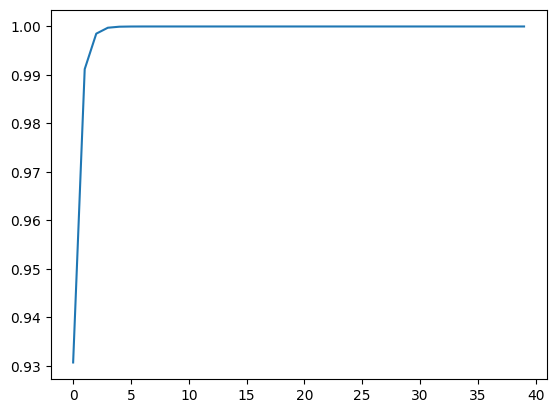

In [20]:
plt.plot(results[2])

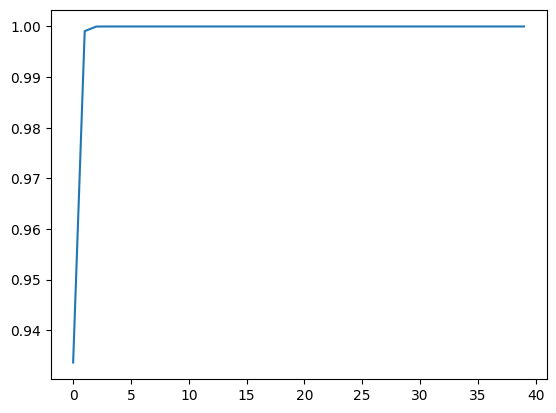

In [21]:
plt.plot(results[3])

In [22]:
results[4]

array([0.0625])

In [23]:
results[0][0].data

array([[[[-0.27862712+0.4897861j ,  0.32769452+0.20381741j],
         [ 0.22308507+0.57901394j,  0.2091186 -0.32372301j]],

        [[-0.37881378+0.30785885j,  0.46709171-0.36785915j],
         [-0.06061722-0.23558652j,  0.03109809+0.58998769j]]],


       [[[ 0.0388458 +0.62173671j, -0.13359858+0.35726343j],
         [-0.45903305-0.31306303j, -0.37754912-0.12322985j]],

        [[ 0.17089545+0.16409986j, -0.16774932+0.56916972j],
         [ 0.44678736-0.21785707j,  0.3760345 +0.45087624j]]]])

In [24]:
results[1][1]

Tensor(shape=(2, 2, 2, 2), inds=('k140_2', 'k141_2', 'b140_1', 'b141_1'), tags=oset(['I58', 'I59', 'I60', 'I61', 'I62', 'I63', 'I64', 'I65', 'I66', 'I67', 'I68', 'I69', 'I70', 'I71', 'I72', 'I73', 'I74', 'I75', 'I76', 'I77', 'I78', 'I79', 'I80', 'I81', 'I82', 'I83', 'I84', 'I85', 'I86', 'I87', 'I88', 'I89', 'I90', 'I91', 'I92', 'I93', 'I94', 'I95', 'I96', 'I97', 'I98', 'I99', 'I100', 'I101', 'I102', 'I103', 'I104', 'I105', 'I106', 'I107', 'I108', 'I109', 'I110', 'I111', 'I112', 'I113', 'I114', 'I115', 'I116', 'I117', 'I118', 'I119', 'I120', 'I121', 'I122', 'I123', 'I124', 'I125', 'I126', 'I127', 'I128', 'I129', 'I130', 'I131', 'I132', 'I133', 'I134', 'I135', 'I136', 'I137', 'I138', 'I139', 'I140', 'I141']))

## Are the boundary operators unique?

In [25]:
def similarity_score(op_1, op_2):
    np_op_1 = op_1.data.reshape(4,4)
    np_op_2 = op_2.data.reshape(4,4)

    cross_term = np.trace(np_op_1@(np_op_2.conj().T))

    return (
        np.linalg.norm(np_op_1)**2
        + np.linalg.norm(np_op_2)**2
        - 2*np.abs(cross_term)
    )

In [26]:
results = [
    find_boundary_operators(
        psi_dict[0],
        60,
        139,
        2,
        20
    )
    for _ in range(30)
]

In [27]:
len(results)

30

In [28]:
def get_all_similarities(op_list):
    if len(op_list) >= 2:
        head, tail = op_list[0], op_list[1:]
        current_similarities = [
            similarity_score(head, other)
            for other in tail
        ]
        return current_similarities + get_all_similarities(tail)
    else:
        return list()

In [29]:
left_sims_1 = get_all_similarities(
    [l[0][0] for l in results]
)

(array([ 3.,  5.,  9., 23., 36., 49., 79., 92., 86., 53.]),
 array([2.56018187, 3.09543062, 3.63067937, 4.16592813, 4.70117688,
        5.23642563, 5.77167439, 6.30692314, 6.84217189, 7.37742064,
        7.9126694 ]),
 <BarContainer object of 10 artists>)

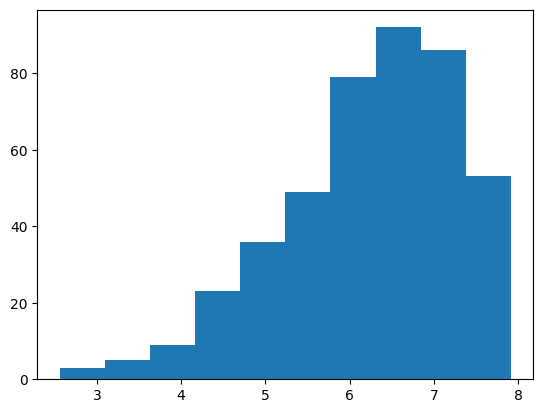

In [30]:
plt.hist(left_sims_1)

In [31]:
pd.Series(left_sims_1).describe()

count    435.000000
mean       6.234041
std        1.033073
min        2.560182
25%        5.641139
50%        6.371509
75%        7.008142
max        7.912669
dtype: float64

In [32]:
left_sims_2 = get_all_similarities(
    [l[0][1] for l in results]
)

(array([ 3.,  5.,  9., 22., 37., 49., 79., 92., 86., 53.]),
 array([2.56018187, 3.09521139, 3.63024091, 4.16527043, 4.70029995,
        5.23532947, 5.77035898, 6.3053885 , 6.84041802, 7.37544754,
        7.91047706]),
 <BarContainer object of 10 artists>)

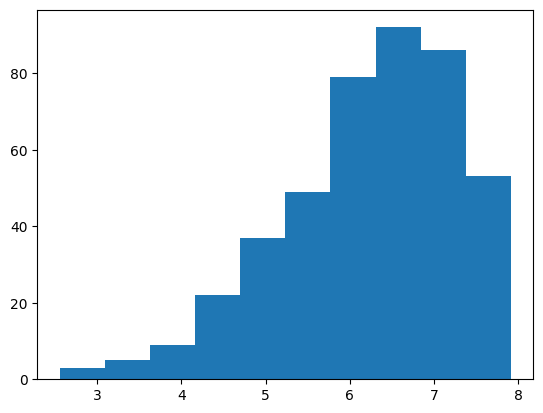

In [33]:
plt.hist(left_sims_2)

In [34]:
pd.Series(left_sims_2).describe()

count    435.000000
mean       6.234065
std        1.033117
min        2.560182
25%        5.641139
50%        6.374766
75%        7.008142
max        7.910477
dtype: float64

In [35]:
left_final_scores = [l[2][-1] for l in results]

In [36]:
pd.Series(left_final_scores).describe()

count    3.000000e+01
mean     9.999999e-01
std      1.893269e-07
min      9.999992e-01
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64

In [37]:
right_sims_1 = get_all_similarities(
    [l[1][0] for l in results]
)

(array([  1.,   1.,   5.,   9.,  24.,  46.,  79., 122.,  85.,  63.]),
 array([1.65291509, 2.2825975 , 2.91227991, 3.54196231, 4.17164472,
        4.80132713, 5.43100953, 6.06069194, 6.69037435, 7.32005675,
        7.94973916]),
 <BarContainer object of 10 artists>)

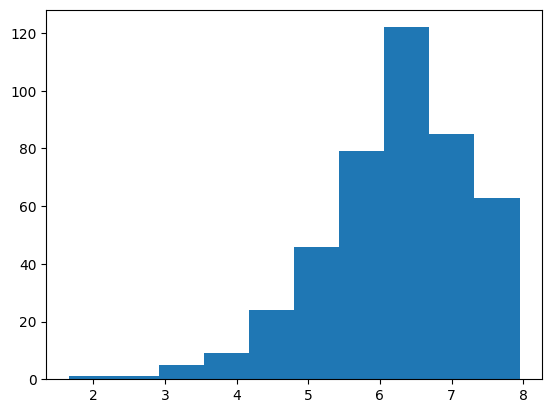

In [38]:
plt.hist(right_sims_1)

In [39]:
pd.Series(right_sims_1).describe()

count    435.000000
mean       6.229122
std        1.012465
min        1.652915
25%        5.621816
50%        6.386699
75%        6.951617
max        7.949739
dtype: float64

In [40]:
right_sims_2 = get_all_similarities(
    [l[1][1] for l in results]
)

(array([  1.,   1.,   5.,   9.,  24.,  46.,  78., 123.,  85.,  63.]),
 array([1.6522317 , 2.28198245, 2.9117332 , 3.54148395, 4.1712347 ,
        4.80098545, 5.4307362 , 6.06048694, 6.69023769, 7.31998844,
        7.94973919]),
 <BarContainer object of 10 artists>)

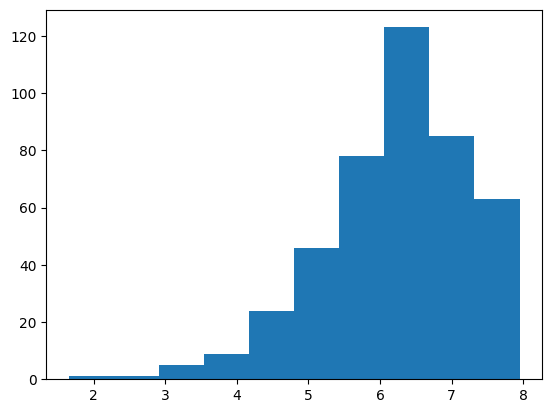

In [41]:
plt.hist(right_sims_2)

In [42]:
pd.Series(right_sims_2).describe()

count    435.000000
mean       6.229106
std        1.012530
min        1.652232
25%        5.621816
50%        6.386768
75%        6.951617
max        7.949739
dtype: float64

In [43]:
right_final_scores = [l[3][-1] for l in results]

In [44]:
pd.Series(left_final_scores).describe()

count    3.000000e+01
mean     9.999999e-01
std      1.893269e-07
min      9.999992e-01
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64

Take an example:

In [45]:
right_sims_1[0]

7.114715018693308

In [46]:
results[0][1][1].data

array([[[[-0.01757028+0.41872519j,  0.3391652 +0.13613378j],
         [ 0.26486339-0.04910528j,  0.22583467-0.75314661j]],

        [[-0.15567912-0.79334346j, -0.11347414+0.12932791j],
         [ 0.22027641+0.22281162j, -0.14305862-0.44512424j]]],


       [[[-0.27647371-0.2260603j ,  0.10322118-0.74337035j],
         [-0.09169045-0.39221068j,  0.3692503 -0.10306694j]],

        [[ 0.03910007-0.20410994j,  0.02588727+0.5224062j ],
         [-0.44571439-0.68437684j,  0.08464127-0.09505156j]]]])

In [47]:
results[1][1][1].data

array([[[[-0.61346052+0.18742303j, -0.57276869-0.04582762j],
         [ 0.40092188-0.11053482j, -0.11191238-0.26998885j]],

        [[-0.56526389-0.17461463j,  0.46532098+0.39249331j],
         [ 0.22568757+0.12097142j, -0.12270545+0.44585452j]]],


       [[[ 0.32240067-0.3001121j , -0.21988927+0.12654606j],
         [ 0.55654373-0.41406995j,  0.37719277+0.34373844j]],

        [[-0.15688014+0.14108304j, -0.44029832+0.20256712j],
         [-0.40232507+0.34411398j,  0.53343887+0.3946533j ]]]])

In [48]:
X1 = results[0][1][1].data
X2 = results[1][1][1].data

diffs = list()

for i in np.linspace(0, 1, 100):
    phase = np.exp(2*np.pi*1j*i)
    diffs.append(np.linalg.norm(X1 - phase*X2)**2)

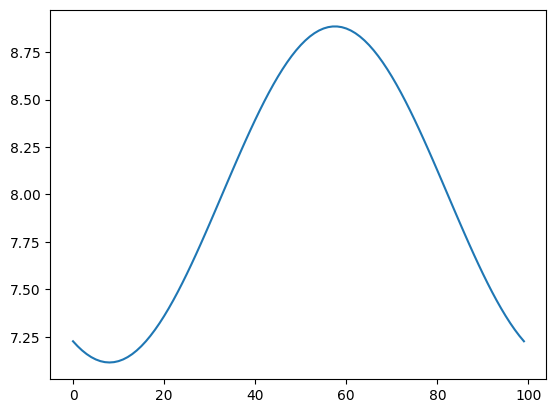

In [49]:
plt.plot(diffs)

In [50]:
np.min(diffs)

7.11471501869483

In [51]:
right_sims_2[0]

7.114715018693259

Consistent. So there is degeneracy. Dang.

## Compute "true" boundary operators.

In [58]:
def get_direct_environment_matrices(psi, leftmost_symmetry_site,
    rightmost_symmetry_site, num_boundary_sites):
    
    symmetry_sites = list(range(leftmost_symmetry_site, rightmost_symmetry_site+1))
    all_sites = list(range(
        leftmost_symmetry_site-num_boundary_sites,
        rightmost_symmetry_site+1+num_boundary_sites
    ))

    left_boundary_sites = list(range(
        leftmost_symmetry_site-num_boundary_sites,
        leftmost_symmetry_site
    ))

    right_boundary_sites = list(range(
        rightmost_symmetry_site+1,
        rightmost_symmetry_site+1+num_boundary_sites
    ))

    psi_2 = psi.copy(deep=True)
    symmetry_tags = [f'I{i}' for i in symmetry_sites]
    for t in psi_2.select(symmetry_tags, which='any'):
        t.conj(inplace=True)

    psi_b = (
        psi
        .conj()
        .reindex({f'k{i}':f'b{i}' for i in all_sites})
    )

    x_gates = [
        x_gate.copy().reindex({'b': f'b{i}', 'k': f'k{i}'})
        for i in symmetry_sites
    ]
    
    leftright_env_matrix = (
        qtn.tensor_core.TensorNetwork(
            [
                psi_2,
                psi_b,
                *x_gates
            ]
        )
        .contract()
    )

    left_boundary_indices = [
        f'{bk}{i}'
        for bk in ['b', 'k']
        for i in left_boundary_sites
    ]

    svd = leftright_env_matrix.split(
        left_inds=left_boundary_indices,
        absorb=None,
        bond_ind='s'
    )

    left_right_singular_vals = svd.tensors[1].data

    left_env_matrix = svd.tensors[0].isel({'s': 0})
    right_env_matrix = svd.tensors[2].isel({'s': 0})

    return (left_env_matrix, right_env_matrix, left_right_singular_vals)

In [53]:
leftmost_symmetry_site = 60
rightmost_symmetry_site = 139
num_boundary_sites = 2

In [56]:
psi = psi_dict[0]

In [60]:
direct_env_matrices = get_direct_environment_matrices(
    psi,
    leftmost_symmetry_site,
    rightmost_symmetry_site,
    num_boundary_sites
)

In [61]:
direct_env_matrices

(Tensor(shape=(2, 2, 2, 2), inds=('b58', 'b59', 'k58', 'k59'), tags=oset(['I0', 'I1', 'I2', 'I3', 'I4', 'I5', 'I6', 'I7', 'I8', 'I9', 'I10', 'I11', 'I12', 'I13', 'I14', 'I15', 'I16', 'I17', 'I18', 'I19', 'I20', 'I21', 'I22', 'I23', 'I24', 'I25', 'I26', 'I27', 'I28', 'I29', 'I30', 'I31', 'I32', 'I33', 'I34', 'I35', 'I36', 'I37', 'I38', 'I39', 'I40', 'I41', 'I42', 'I43', 'I44', 'I45', 'I46', 'I47', 'I48', 'I49', 'I50', 'I51', 'I52', 'I53', 'I54', 'I55', 'I56', 'I57', 'I58', 'I59', 'I60', 'I61', 'I62', 'I63', 'I64', 'I65', 'I66', 'I67', 'I68', 'I69', 'I70', 'I71', 'I72', 'I73', 'I74', 'I75', 'I76', 'I77', 'I78', 'I79', 'I80', 'I81', 'I82', 'I83', 'I84', 'I85', 'I86', 'I87', 'I88', 'I89', 'I90', 'I91', 'I92', 'I93', 'I94', 'I95', 'I96', 'I97', 'I98', 'I99', 'I100', 'I101', 'I102', 'I103', 'I104', 'I105', 'I106', 'I107', 'I108', 'I109', 'I110', 'I111', 'I112', 'I113', 'I114', 'I115', 'I116', 'I117', 'I118', 'I119', 'I120', 'I121', 'I122', 'I123', 'I124', 'I125', 'I126', 'I127', 'I128', 'I12

In [63]:
np.round(direct_env_matrices[0].data, 3)

array([[[[-0. , -0.5],
         [ 0. , -0. ]],

        [[ 0.5, -0. ],
         [-0. , -0. ]]],


       [[[ 0. ,  0. ],
         [-0. ,  0.5]],

        [[ 0. , -0. ],
         [-0.5,  0. ]]]])

In [64]:
np.round(direct_env_matrices[1].data, 3)

array([[[[ 0. ,  0. ],
         [-0.5, -0. ]],

        [[ 0. ,  0. ],
         [ 0. ,  0.5]]],


       [[[ 0.5, -0. ],
         [-0. ,  0. ]],

        [[ 0. , -0.5],
         [-0. , -0. ]]]])

In [95]:
kb_transpose_dict = {
    'k': 'b',
    'b': 'k'
}

def tranpose_tensor_network(t):
    transpose_reindex_dict = {
        ind: kb_transpose_dict[ind[0]] + ind[1:]
        for ind in t.inds
    }

    return t.reindex(transpose_reindex_dict)

In [96]:
def hermitian_conjugate_tensor(t):
    return tranpose_tensor_network(t.conj())

In [97]:
def get_true_boundary_operator(environment_matrix):
    k_inds = [
        ind for ind in environment_matrix.inds
        if ind[0] == 'k'
    ]

    svd = environment_matrix.split(
        left_inds=k_inds,
        absorb=None,
        bond_ind='s'
    )

    boundary_op_hc = (svd.tensors[0] & svd.tensors[2])^...
    boundary_op = hermitian_conjugate_tensor(boundary_op_hc)

    return boundary_op

In [98]:
left_boundary_op = get_true_boundary_operator(direct_env_matrices[0])
right_boundary_op = get_true_boundary_operator(direct_env_matrices[1])

In [99]:
left_boundary_op

Tensor(shape=(2, 2, 2, 2), inds=('b58', 'b59', 'k58', 'k59'), tags=oset(['I0', 'I1', 'I2', 'I3', 'I4', 'I5', 'I6', 'I7', 'I8', 'I9', 'I10', 'I11', 'I12', 'I13', 'I14', 'I15', 'I16', 'I17', 'I18', 'I19', 'I20', 'I21', 'I22', 'I23', 'I24', 'I25', 'I26', 'I27', 'I28', 'I29', 'I30', 'I31', 'I32', 'I33', 'I34', 'I35', 'I36', 'I37', 'I38', 'I39', 'I40', 'I41', 'I42', 'I43', 'I44', 'I45', 'I46', 'I47', 'I48', 'I49', 'I50', 'I51', 'I52', 'I53', 'I54', 'I55', 'I56', 'I57', 'I58', 'I59', 'I60', 'I61', 'I62', 'I63', 'I64', 'I65', 'I66', 'I67', 'I68', 'I69', 'I70', 'I71', 'I72', 'I73', 'I74', 'I75', 'I76', 'I77', 'I78', 'I79', 'I80', 'I81', 'I82', 'I83', 'I84', 'I85', 'I86', 'I87', 'I88', 'I89', 'I90', 'I91', 'I92', 'I93', 'I94', 'I95', 'I96', 'I97', 'I98', 'I99', 'I100', 'I101', 'I102', 'I103', 'I104', 'I105', 'I106', 'I107', 'I108', 'I109', 'I110', 'I111', 'I112', 'I113', 'I114', 'I115', 'I116', 'I117', 'I118', 'I119', 'I120', 'I121', 'I122', 'I123', 'I124', 'I125', 'I126', 'I127', 'I128', 'I129', 'I130', 'I131', 'I132', 'I133', 'I134', 'I135', 'I136', 'I137', 'I138', 'I139', 'I140', 'I141', 'I142', 'I143', 'I144', 'I145', 'I146', 'I147', 'I148', 'I149', 'I150', 'I151', 'I152', 'I153', 'I154', 'I155', 'I156', 'I157', 'I158', 'I159', 'I160', 'I161', 'I162', 'I163', 'I164', 'I165', 'I166', 'I167', 'I168', 'I169', 'I170', 'I171', 'I172', 'I173', 'I174', 'I175', 'I176', 'I177', 'I178', 'I179', 'I180', 'I181', 'I182', 'I183', 'I184', 'I185', 'I186', 'I187', 'I188', 'I189', 'I190', 'I191', 'I192', 'I193', 'I194', 'I195', 'I196', 'I197', 'I198', 'I199']))

In [100]:
np.round(left_boundary_op.data, 3)

array([[[[-0.,  1.],
         [ 0., -0.]],

        [[-1., -0.],
         [ 0., -0.]]],


       [[[ 0., -0.],
         [-0., -1.]],

        [[ 0.,  0.],
         [ 1., -0.]]]])

In [105]:
np.round(tranpose_tensor_network(left_boundary_op).data, 3)

array([[[[-0.,  1.],
         [ 0., -0.]],

        [[-1., -0.],
         [ 0., -0.]]],


       [[[ 0., -0.],
         [-0., -1.]],

        [[ 0.,  0.],
         [ 1., -0.]]]])

In [88]:
right_boundary_op

Tensor(shape=(2, 2, 2, 2), inds=('k140', 'k141', 'b140', 'b141'), tags=oset(['I0', 'I1', 'I2', 'I3', 'I4', 'I5', 'I6', 'I7', 'I8', 'I9', 'I10', 'I11', 'I12', 'I13', 'I14', 'I15', 'I16', 'I17', 'I18', 'I19', 'I20', 'I21', 'I22', 'I23', 'I24', 'I25', 'I26', 'I27', 'I28', 'I29', 'I30', 'I31', 'I32', 'I33', 'I34', 'I35', 'I36', 'I37', 'I38', 'I39', 'I40', 'I41', 'I42', 'I43', 'I44', 'I45', 'I46', 'I47', 'I48', 'I49', 'I50', 'I51', 'I52', 'I53', 'I54', 'I55', 'I56', 'I57', 'I58', 'I59', 'I60', 'I61', 'I62', 'I63', 'I64', 'I65', 'I66', 'I67', 'I68', 'I69', 'I70', 'I71', 'I72', 'I73', 'I74', 'I75', 'I76', 'I77', 'I78', 'I79', 'I80', 'I81', 'I82', 'I83', 'I84', 'I85', 'I86', 'I87', 'I88', 'I89', 'I90', 'I91', 'I92', 'I93', 'I94', 'I95', 'I96', 'I97', 'I98', 'I99', 'I100', 'I101', 'I102', 'I103', 'I104', 'I105', 'I106', 'I107', 'I108', 'I109', 'I110', 'I111', 'I112', 'I113', 'I114', 'I115', 'I116', 'I117', 'I118', 'I119', 'I120', 'I121', 'I122', 'I123', 'I124', 'I125', 'I126', 'I127', 'I128', 'I129', 'I130', 'I131', 'I132', 'I133', 'I134', 'I135', 'I136', 'I137', 'I138', 'I139', 'I140', 'I141', 'I142', 'I143', 'I144', 'I145', 'I146', 'I147', 'I148', 'I149', 'I150', 'I151', 'I152', 'I153', 'I154', 'I155', 'I156', 'I157', 'I158', 'I159', 'I160', 'I161', 'I162', 'I163', 'I164', 'I165', 'I166', 'I167', 'I168', 'I169', 'I170', 'I171', 'I172', 'I173', 'I174', 'I175', 'I176', 'I177', 'I178', 'I179', 'I180', 'I181', 'I182', 'I183', 'I184', 'I185', 'I186', 'I187', 'I188', 'I189', 'I190', 'I191', 'I192', 'I193', 'I194', 'I195', 'I196', 'I197', 'I198', 'I199']))

In [102]:
np.round(right_boundary_op.data, 3)

array([[[[ 0., -0.],
         [-1., -0.]],

        [[-0.,  0.],
         [-0.,  1.]]],


       [[[ 1.,  0.],
         [ 0., -0.]],

        [[ 0., -1.],
         [ 0.,  0.]]]])

Looks right to me.

In [104]:
np.round(tranpose_tensor_network(right_boundary_op).data, 3)

array([[[[ 0., -0.],
         [-1., -0.]],

        [[-0.,  0.],
         [-0.,  1.]]],


       [[[ 1.,  0.],
         [ 0., -0.]],

        [[ 0., -1.],
         [ 0.,  0.]]]])

Both boundary operators are conjugation and transposition invariant, so don't need to worry about orientation plugging into to the partial transpose environment matrices.

In [106]:
symmetry_sites = list(range(leftmost_symmetry_site, rightmost_symmetry_site+1))
all_sites = list(range(
    leftmost_symmetry_site-num_boundary_sites,
    rightmost_symmetry_site+1+num_boundary_sites
))

rho = psi.partial_trace_to_mpo(
    all_sites,
    rescale_sites=False
)

rho_2 = rho.copy()

rho.reindex(
    {f'{s}{i}': f'{s}{i}_1' for s in ['k', 'b'] for i in all_sites},
    inplace=True
)

rho_2.reindex(
    {f'{s}{i}': f'{s}{i}_2' for s in ['k', 'b'] for i in all_sites},
    inplace=True
)

x_gates_b = [
    x_gate.copy().reindex({'b': f'b{i}_1', 'k': f'b{i}_2'})
    for i in symmetry_sites
]

x_gates_k = [
    x_gate.copy().reindex({'b': f'k{i}_1', 'k': f'k{i}_2'})
    for i in symmetry_sites
]

two_sided_environment_matrix = qtn.tensor_core.TensorNetwork(
    [
        rho,
        rho_2,
        *x_gates_b,
        *x_gates_k
    ]
)
two_sided_environment_matrix.contract(inplace=False)

left_boundary_sites = list(range(
    leftmost_symmetry_site-num_boundary_sites,
    leftmost_symmetry_site
))

right_boundary_sites = list(range(
    rightmost_symmetry_site+1,
    rightmost_symmetry_site+1+num_boundary_sites
))

left_boundary_indices = [
    f'{bk}{i}_{j}'
    for bk in ['b', 'k']
    for i in left_boundary_sites
    for j in [1, 2]
]

split_two_sided_environment_matrix = two_sided_environment_matrix.split(
    left_inds=left_boundary_indices,
    absorb=None,
    bond_ind='s'
)

two_sided_sing_vals = (
    split_two_sided_environment_matrix
    .tensors[1]
    .data
)

left_env_matrix = split_two_sided_environment_matrix.tensors[0].isel({'s': 0})
right_env_matrix = split_two_sided_environment_matrix.tensors[2].isel({'s': 0})

In [107]:
left_env_matrix

Tensor(shape=(2, 2, 2, 2, 2, 2, 2, 2), inds=('b58_1', 'b58_2', 'b59_1', 'b59_2', 'k58_1', 'k58_2', 'k59_1', 'k59_2'), tags=oset(['I58', 'I59', 'I60', 'I61', 'I62', 'I63', 'I64', 'I65', 'I66', 'I67', 'I68', 'I69', 'I70', 'I71', 'I72', 'I73', 'I74', 'I75', 'I76', 'I77', 'I78', 'I79', 'I80', 'I81', 'I82', 'I83', 'I84', 'I85', 'I86', 'I87', 'I88', 'I89', 'I90', 'I91', 'I92', 'I93', 'I94', 'I95', 'I96', 'I97', 'I98', 'I99', 'I100', 'I101', 'I102', 'I103', 'I104', 'I105', 'I106', 'I107', 'I108', 'I109', 'I110', 'I111', 'I112', 'I113', 'I114', 'I115', 'I116', 'I117', 'I118', 'I119', 'I120', 'I121', 'I122', 'I123', 'I124', 'I125', 'I126', 'I127', 'I128', 'I129', 'I130', 'I131', 'I132', 'I133', 'I134', 'I135', 'I136', 'I137', 'I138', 'I139', 'I140', 'I141']))

In [117]:
def add_subscript_to_tensor_inds(t, subscript):
    index_map = {
        ind: f'{ind}_{subscript}' for ind in t.inds
    }

    out = t.reindex(index_map)

    return out

In [118]:
def add_kb_subscript_to_tensor_inds(t, k_subscript, b_subscript):
    k_index_map = {
        ind: f'{ind}_{k_subscript}' for ind in t.inds
        if ind[0] == 'k'
    }

    b_index_map = {
        ind: f'{ind}_{b_subscript}' for ind in t.inds
        if ind[0] == 'b'
    }

    out = (
        t
        .reindex(k_index_map)
        .reindex(b_index_map)
    )

    return out

In [120]:
(
    left_env_matrix
    & add_kb_subscript_to_tensor_inds(left_boundary_op, '1', '2')
    & add_kb_subscript_to_tensor_inds(left_boundary_op, '2', '1')
) ^...

-1.0

In [121]:
(
    right_env_matrix
    & add_kb_subscript_to_tensor_inds(right_boundary_op, '1', '2')
    & add_kb_subscript_to_tensor_inds(right_boundary_op, '2', '1')
) ^...

-1.0000000000000002

So the boundary operators do indeed optimize. There are just other possible solutions.

## Plug in partial transpose boundary operators to direct environment matrices

In [137]:
(direct_env_matrices[0] & left_boundary_op)^...

-2.0

In [140]:
(direct_env_matrices[1] & right_boundary_op)^...

-2.0

In [124]:
def clean_op_indices(op_t):
    clean_reindex_dict = {
        ind: ('').join(ind.split('_')[:-1])
        for ind in op_t.inds
    }

    return op_t.reindex(clean_reindex_dict)

In [123]:
results[0][1][0]

Tensor(shape=(2, 2, 2, 2), inds=('k140_1', 'k141_1', 'b140_2', 'b141_2'), tags=oset(['I58', 'I59', 'I60', 'I61', 'I62', 'I63', 'I64', 'I65', 'I66', 'I67', 'I68', 'I69', 'I70', 'I71', 'I72', 'I73', 'I74', 'I75', 'I76', 'I77', 'I78', 'I79', 'I80', 'I81', 'I82', 'I83', 'I84', 'I85', 'I86', 'I87', 'I88', 'I89', 'I90', 'I91', 'I92', 'I93', 'I94', 'I95', 'I96', 'I97', 'I98', 'I99', 'I100', 'I101', 'I102', 'I103', 'I104', 'I105', 'I106', 'I107', 'I108', 'I109', 'I110', 'I111', 'I112', 'I113', 'I114', 'I115', 'I116', 'I117', 'I118', 'I119', 'I120', 'I121', 'I122', 'I123', 'I124', 'I125', 'I126', 'I127', 'I128', 'I129', 'I130', 'I131', 'I132', 'I133', 'I134', 'I135', 'I136', 'I137', 'I138', 'I139', 'I140', 'I141']))

In [132]:
pt_op_in_right_direct_env_scores = list()

for l in results:
    ops = l[1]

    for op in ops:
        clean_op = clean_op_indices(op)
        clean_ops = [
            clean_op,
            clean_op.conj(),
            tranpose_tensor_network(clean_op),
            tranpose_tensor_network(clean_op).conj()
        ]
        scores = [
            np.abs((x & direct_env_matrices[1]) ^ ...)
            for x in clean_ops
        ]
        pt_op_in_right_direct_env_scores.append(scores)

In [133]:
np.round(np.array(pt_op_in_right_direct_env_scores), 3)

array([[0.673, 0.673, 0.673, 0.673],
       [0.673, 0.673, 0.673, 0.673],
       [0.123, 0.123, 0.123, 0.123],
       [0.123, 0.123, 0.123, 0.123],
       [0.082, 0.082, 0.082, 0.082],
       [0.082, 0.082, 0.082, 0.082],
       [0.95 , 0.95 , 0.95 , 0.95 ],
       [0.95 , 0.95 , 0.95 , 0.95 ],
       [0.499, 0.499, 0.499, 0.499],
       [0.499, 0.499, 0.499, 0.499],
       [1.178, 1.178, 1.178, 1.178],
       [1.178, 1.178, 1.178, 1.178],
       [0.309, 0.309, 0.309, 0.309],
       [0.309, 0.309, 0.309, 0.309],
       [0.377, 0.377, 0.377, 0.377],
       [0.377, 0.377, 0.377, 0.377],
       [0.101, 0.101, 0.101, 0.101],
       [0.101, 0.101, 0.101, 0.101],
       [0.288, 0.288, 0.288, 0.288],
       [0.288, 0.288, 0.288, 0.288],
       [0.256, 0.256, 0.256, 0.256],
       [0.256, 0.256, 0.256, 0.256],
       [0.391, 0.391, 0.391, 0.391],
       [0.391, 0.391, 0.391, 0.391],
       [0.216, 0.216, 0.216, 0.216],
       [0.216, 0.216, 0.216, 0.216],
       [0.136, 0.136, 0.136, 0.136],
 

In [135]:
pt_op_in_left_direct_env_scores = list()

for l in results:
    ops = l[0]

    for op in ops:
        clean_op = clean_op_indices(op)
        clean_ops = [
            clean_op,
            clean_op.conj(),
            tranpose_tensor_network(clean_op),
            tranpose_tensor_network(clean_op).conj()
        ]
        scores = [
            np.abs((x & direct_env_matrices[0]) ^ ...)
            for x in clean_ops
        ]
        pt_op_in_left_direct_env_scores.append(scores)

In [136]:
np.round(np.array(pt_op_in_right_direct_env_scores), 3)

array([[0.673, 0.673, 0.673, 0.673],
       [0.673, 0.673, 0.673, 0.673],
       [0.123, 0.123, 0.123, 0.123],
       [0.123, 0.123, 0.123, 0.123],
       [0.082, 0.082, 0.082, 0.082],
       [0.082, 0.082, 0.082, 0.082],
       [0.95 , 0.95 , 0.95 , 0.95 ],
       [0.95 , 0.95 , 0.95 , 0.95 ],
       [0.499, 0.499, 0.499, 0.499],
       [0.499, 0.499, 0.499, 0.499],
       [1.178, 1.178, 1.178, 1.178],
       [1.178, 1.178, 1.178, 1.178],
       [0.309, 0.309, 0.309, 0.309],
       [0.309, 0.309, 0.309, 0.309],
       [0.377, 0.377, 0.377, 0.377],
       [0.377, 0.377, 0.377, 0.377],
       [0.101, 0.101, 0.101, 0.101],
       [0.101, 0.101, 0.101, 0.101],
       [0.288, 0.288, 0.288, 0.288],
       [0.288, 0.288, 0.288, 0.288],
       [0.256, 0.256, 0.256, 0.256],
       [0.256, 0.256, 0.256, 0.256],
       [0.391, 0.391, 0.391, 0.391],
       [0.391, 0.391, 0.391, 0.391],
       [0.216, 0.216, 0.216, 0.216],
       [0.216, 0.216, 0.216, 0.216],
       [0.136, 0.136, 0.136, 0.136],
 

So they're not reaching as high as they could be...